<a href="https://colab.research.google.com/github/IanWorldHi/MLLearn/blob/main/pytorcher/torchWFFUNDCollab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Pytorch Workflow Fundamentals

https://colab.research.google.com/drive/1S9MKCSQyCGwLQaFPPxKjdLYaPggPfWuO#scrollTo=PrXqJlSLdiaX

1. Ready data (into tensors)
- Creating a training set (model learns from this 80), test set (model tested on this data 10) and (sometimes) validation set (tuned on this 10)
2. Build || pick pretrained model (pick loss funciton & optimizer -> build training loop)
3. Fit model to data & make prediction
4. Evaluate model
5. Improve w/ experimentation
6. Save & reload trained model

In [1]:
import torch
from torch import nn
import matplotlib.pyplot as plt
from pathlib import Path
#torch.__version__

In [ ]:
#known parameters
weight = 0.7
bias = 0.3

#Creating data
start = 0
end = 1
step = 0.01
x = torch.arange(start, end, step).unsqueeze(dim=1)
y = weight*x + bias
x[:5], y[:5]


(tensor([[0.0000],
         [0.0100],
         [0.0200],
         [0.0300],
         [0.0400]]),
 tensor([[0.3000],
         [0.3070],
         [0.3140],
         [0.3210],
         [0.3280]]))

In [ ]:
split80 = int(0.8*len(x))
xTrainSet, yTrainSet = x[:split80], y[:split80]
xTestSet, yTestSet = x[split80:], y[split80:]

In [1]:
#Ploting for visualization
def plot(xTrainSet=xTrainSet, yTrainSet=yTrainSet, xTestSet=xTestSet, yTestSet=yTestSet, predictions=None):
  plt.figure(figsize=(5, 5))
  plt.scatter(xTrainSet, yTrainSet, c="b", s=4, label="Training data")
  plt.scatter(xTestSet, yTestSet, c="g", s=4, label="Training data")
  plt.legend(prop={"size": 14})
  if predictions is not None:
    plt.scatter(xTestSet, predictions, c="r", s=4, label="Predictions")
plot(xTrainSet, yTrainSet, xTestSet, yTestSet)

NameError: name 'xTrainSet' is not defined

Building Model: (All nn.Module subclasses requier a forward func)

In [ ]:
class LinearRegressionModel(nn.Module): #Inheriting nn.Module which is like all of pytorch
  def __init__(self):
    super().__init__()
    self.weights = nn.Parameter(torch.randn(1), requires_grad=True) #default type float32, requires_grad is also true by default
    #Parameter just stores tensors
    #Autograd is if gradients calculated automatically (tracked for gradient descent)
    self.bias = nn.Parameter(torch.randn(1))
  def forward(self, x: torch.Tensor) -> torch.Tensor: #computation #the datatype
    return self.weights*x +self.bias #linear regression model ax+b

In [ ]:
torch.manual_seed(42)
model000 = LinearRegressionModel()
list(model000.parameters()), model000.state_dict()

([Parameter containing:
  tensor([0.3367], requires_grad=True),
  Parameter containing:
  tensor([0.1288], requires_grad=True)],
 OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))]))

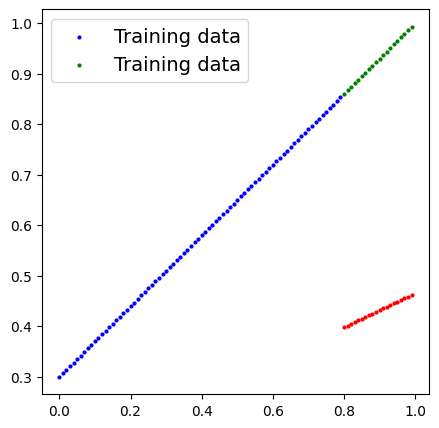

In [ ]:
with torch.inference_mode(): #with ensures setup/takedown are performed automatically regardless of errors (context manager)
  #it turns off grad & stuff to be faster
  yPrediction = model000(xTestSet)
#inference or predictions
plot(xTrainSet, yTrainSet, xTestSet, yTestSet, yPrediction)

Train: Loss function (measures how wrong predictions are) & Optimizer (Tells model how to update internal parameters to lessen loss)

Some common ones: SGD (Stochastic gradient descent), Adam optimizer, MAE (mean absolute error) loss function for regression problems, binary cross entropy loss function for classification problems
Hyperparameter: a parameter set by engineer, learning rate is one

In [ ]:
lossFx = nn.L1Loss() #MAE loss same
optimizer = torch.optim.SGD(params=model000.parameters(), lr=0.01) #parameters to optimize, and then learning rate

Optimization Loop: Training Loop & Testing Loop
Training Loop:
1. Forward pass
2. Calculate loss
3. Zero gradients (they're accmulated by default)
4. Backpropogation on loss (Computes gradient of loss with respect for every parameter to be updated ~like how much the weight contributed to loss)
5. Update optimizer (gradient descent - updating parameters with requires_grad=True)
Testing Loop:
- model.eval() to say we're evaluating not training
- torch.inference_mode() - disables gradient tracking
- calculate and display loss
- epoch: forward pass of data

In [ ]:
passes = 100 #epoches
trainLossV = [] #values
testLossV = []
passCount = []

for passer in range(passes):
  model000.train() #puts it in training mode (default)
  yPrediction = model000(xTrainSet)
  loss = lossFx(yPrediction, yTrainSet)
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()
  model000.eval()
  with torch.inference_mode():
    testPrediction = model000(xTestSet)
    testLoss = lossFx(testPrediction, yTestSet)
    if passer%10==0:
      passCount.append(passer)
      trainLossV.append(loss.detach().numpy())
      testLossV.append(testLoss.detach().numpy())
      print(f"Epoch: {passer} | MAE Train Loss: {loss} | MAE Test Loss: {testLoss} ")


Epoch: 0 | MAE Train Loss: 0.31469792127609253 | MAE Test Loss: 0.48281747102737427 
Epoch: 10 | MAE Train Loss: 0.19909533858299255 | MAE Test Loss: 0.3474648892879486 
Epoch: 20 | MAE Train Loss: 0.08958515524864197 | MAE Test Loss: 0.21752354502677917 
Epoch: 30 | MAE Train Loss: 0.05288771912455559 | MAE Test Loss: 0.1439102590084076 
Epoch: 40 | MAE Train Loss: 0.045192889869213104 | MAE Test Loss: 0.11271438747644424 
Epoch: 50 | MAE Train Loss: 0.04140976816415787 | MAE Test Loss: 0.09821617603302002 
Epoch: 60 | MAE Train Loss: 0.03795855492353439 | MAE Test Loss: 0.0888485461473465 
Epoch: 70 | MAE Train Loss: 0.034532517194747925 | MAE Test Loss: 0.08085694909095764 
Epoch: 80 | MAE Train Loss: 0.03110707364976406 | MAE Test Loss: 0.07252134382724762 
Epoch: 90 | MAE Train Loss: 0.027681414037942886 | MAE Test Loss: 0.06452975422143936 


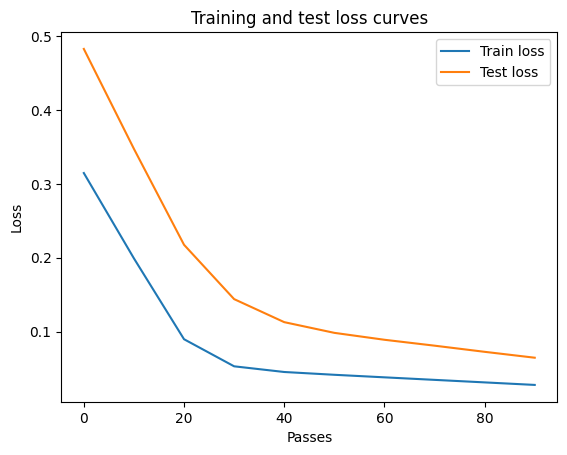

In [ ]:
#Plotting loss curves
plt.plot(passCount, trainLossV, label="Train loss")
plt.plot(passCount, testLossV, label="Test loss")
plt.title("Training and test loss curves")
plt.ylabel("Loss")
plt.xlabel("Passes")
plt.legend()

In [ ]:
print(model000.state_dict())
weight, bias

OrderedDict({'weights': tensor([0.5792]), 'bias': tensor([0.3508])})


(0.7, 0.3)

In [ ]:
Predictions:

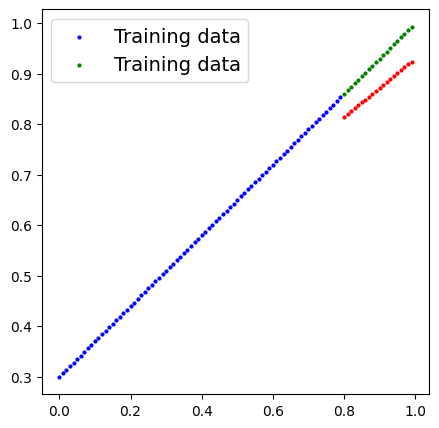

In [ ]:
model000.eval()
with torch.inference_mode():
  yPrediction = model000(xTestSet)
  plot(xTrainSet, yTrainSet, xTestSet, yTestSet, yPrediction)


Saving Model: torch.save or torch.load or torch.nn.Module.load_state_dict
- Note: pickle/unpickle is NOT secure, only unpickle data you trust
- Recommended: save state_dict (weights and bias)

In [ ]:
#from pathlib import Path
MODELPATH = Path("models")
MODELPATH.mkdir(parents=True, exist_ok=True)
MODELNAME = "model000_linearReg.pth"
MODELSAVEPATH = MODELPATH/MODELNAME
torch.save(obj=model000.state_dict(), f=MODELSAVEPATH)

fatal: not a git repository (or any of the parent directories): .git
